##  Install Required Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm shap lime plotly streamlit -q

In [ ]:
## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

import os 
import shap
import joblib

print('All libraries imported successfully!')

In [ ]:
df=pd.read_csv("data/dataset.csv")
df.shape
df.head()

In [ ]:
df.isnull().sum()
print("duplicated values:",df.duplicated().sum())

In [ ]:
df=df.dropna()
df=df.drop_duplicates()

In [ ]:
corr_matrix= df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap="YlGnBu")
plt.show()

## Feature engineering and encoding

In [ ]:
#  Popularity normalization 
df['popularity'] = df['popularity'] / 100

#  Duration in minutes 
df['duration_mins'] = df["duration_ms"] / 60000

# Encoded explicit column (true=1 | false=0)
df['explicit'] = df['explicit'].astype(int)

# Encoded track_genre 
le=LabelEncoder()
df["encoded_genre"] = le.fit_transform(df['track_genre'])

# Mood score: average of valence and energy
df["mood_score"] = (df["valence"] + df["energy"]) / 2

# Hit label: 1 if popularity>=0.75 else 0
df["hit"] = (df["popularity"] >= 0.75).astype(int)

print("Features engineered and encoded")


## Scaling the features


In [ ]:
#Scale the audio features
features = ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_mins']
scaler=MinMaxScaler()

# Make a copy of df 
df_scaled=df.copy()
df_scaled[features]=scaler.fit_transform(df[features])

## Save the clean data

In [ ]:
os.makedirs('data', exist_ok=True)
df.to_csv('data/cleaned_spotify', index=False)
print("new csv created")

In [ ]:
df_scaled.head()

## Exploratory Data Analysis

In [ ]:
# Top 20 genres by average popularity
top_genres=df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(20)
fig = px.bar(x=top_genres.index, y=top_genres.values,
    title='Top 20 Genres by Average Popularity',
    labels={'x': 'Genre', 'y': 'Average Popularity'},
    color=top_genres.values, 
    color_continuous_scale='Viridis')
fig.show()
plt.show()



In [ ]:
df[features].hist(bins=20, figsize=(15,10))
plt.tight_layout()
plt.show()

In [ ]:
# Correlation heatmap 
corr_features = features + ["popularity"]
corr=df[corr_features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGnBu')
plt.tight_layout()
plt.show()

---
## HIT PREDICTION

In [49]:

X= df[features]
y= df['hit']

print("Hit songs:", y.sum())
print("Non-hit songs:", len(y) - y.sum())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets")

print("test set shape:", X_test.shape)
print("training set shape:", X_train.shape)
print('Class ratio:', round(y.mean() * 100, 2), '%')


Hit songs: 2831
Non-hit songs: 111168
Data split into training and testing sets
test set shape: (22800, 10)
training set shape: (91199, 10)
Class ratio: 2.48 %


## Train multiple models

In [51]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),   
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state= 42),    
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42)
}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "ROC AUC": round(roc_auc_score(y_test, y_prob), 4)
    })
results_df = pd.DataFrame(results).sort_values(by="ROC AUC", ascending=False)
results_df

    

[LightGBM] [Info] Number of positive: 2305, number of negative: 88894
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2549
[LightGBM] [Info] Number of data points in the train set: 91199, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.025274 -> initscore=-3.652364
[LightGBM] [Info] Start training from score -3.652364


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.9896,0.9138,0.6046,0.7277,0.8951
4,XGBoost,0.9803,0.9053,0.1635,0.2770,0.8927
5,LightGBM,0.9777,0.7647,0.0494,0.0929,0.8754
1,Decision Tree,0.9767,0.4962,0.6198,0.5511,0.8397
3,Gradient Boosting,0.9771,0.7143,0.0095,0.0188,0.7796
0,Logistic Regression,0.9769,0.0000,0.0000,0.0000,0.7218


In [73]:
best_model=models['Random Forest']
y_pred=best_model.predict(X_test)  
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred, target_names=['Non-Hit', 'Hit']))   


Classification Report for Random Forest:
              precision    recall  f1-score   support

     Non-Hit       0.99      1.00      0.99     22274
         Hit       0.91      0.60      0.73       526

    accuracy                           0.99     22800
   macro avg       0.95      0.80      0.86     22800
weighted avg       0.99      0.99      0.99     22800



In [65]:

print("Confusion Matrix for Random Forest:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual Non-Hit', 'Actual Hit'], columns=['Predicted Non-Hit', 'Predicted Hit'])
cm_df

Confusion Matrix for Random Forest:


,Predicted Non-Hit,Predicted Hit
Actual Non-Hit,22244,30
Actual Hit,208,318


In [82]:
## Feature importance for Random Forest
importances = pd.DataFrame(best_model.feature_importances_, index=features, columns=['Importance'])
importances


,Importance
danceability,0.095770
energy,0.098577
loudness,0.112858
speechiness,0.099726
acousticness,0.106973
instrumentalness,0.073766
liveness,0.095895
valence,0.100740
tempo,0.114587
duration_mins,0.101110


AttributeError: 'Axes' object has no attribute 'sort_values'

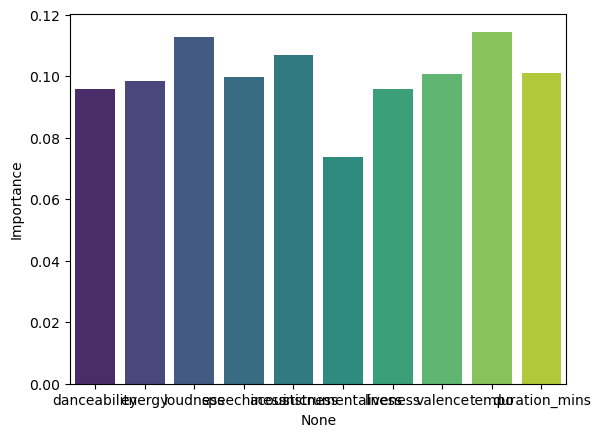

In [ ]:
importances_sorted = importances.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [78]:
rf_balanced=RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
rf_balanced.fit(X_train, y_train) 
y_pred_balanced=rf_balanced.predict(X_test)
print("Classification Report for Balanced Random Forest:")
print(classification_report(y_test, y_pred_balanced, target_names=['Non-Hit', 'Hit']))

Classification Report for Balanced Random Forest:
              precision    recall  f1-score   support

     Non-Hit       0.99      0.99      0.99     22274
         Hit       0.64      0.66      0.65       526

    accuracy                           0.98     22800
   macro avg       0.82      0.83      0.82     22800
weighted avg       0.98      0.98      0.98     22800



In [79]:
new_cm = pd.DataFrame(confusion_matrix(y_test, y_pred_balanced), index=['Actual Non-Hit', 'Actual Hit'], columns=['Predicted Non-Hit', 'Predicted Hit'])
new_cm

,Predicted Non-Hit,Predicted Hit
Actual Non-Hit,22079,195
Actual Hit,178,348


In [80]:
y_prob = best_model.predict_proba(X_test)[:,1]
y_pred_custom=(y_prob >= 0.3).astype(int)
print("Classification Report for Custom Threshold (0.3) Random Forest:")
print(classification_report(y_test, y_pred_custom, target_names=['Non-Hit', 'Hit']))

Classification Report for Custom Threshold (0.3) Random Forest:
              precision    recall  f1-score   support

     Non-Hit       0.99      1.00      0.99     22274
         Hit       0.85      0.64      0.73       526

    accuracy                           0.99     22800
   macro avg       0.92      0.82      0.86     22800
weighted avg       0.99      0.99      0.99     22800

